In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [24]:
bike_df = pd.read_csv('resources/day.csv')
print(bike_df.head())
print(bike_df.shape)
print("Target column 'cnt' stats:")
print(bike_df['cnt'].describe())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
(731, 16)
Target column 'c

In [25]:
model_bike = LinearRegression()
model_bike.fit(X_train_bike, y_train_bike)
y_pred_bike = model_bike.predict(X_test_bike)
rmse_bike = np.sqrt(mean_squared_error(y_test_bike, y_pred_bike))
mae_bike = mean_absolute_error(y_test_bike, y_pred_bike)
print(f"Bike Linear - RMSE: {rmse_bike:.6f}, MAE: {mae_bike:.6f}")


Bike Linear - RMSE: 1546.302650, MAE: 1291.968899


In [26]:
poly_bike = PolynomialFeatures(degree=2)
X_train_poly_bike = poly_bike.fit_transform(X_train_bike)
X_test_poly_bike = poly_bike.transform(X_test_bike)
model_poly_bike = LinearRegression()
model_poly_bike.fit(X_train_poly_bike, y_train_bike)
y_pred_poly_bike = model_poly_bike.predict(X_test_poly_bike)
rmse_poly_bike = np.sqrt(mean_squared_error(y_test_bike, y_pred_poly_bike))
mae_poly_bike = mean_absolute_error(y_test_bike, y_pred_poly_bike)
print(f"Bike Poly deg=2 - RMSE: {rmse_poly_bike:.6f}, MAE: {mae_poly_bike:.6f}")

Bike Poly deg=2 - RMSE: 1559.293587, MAE: 1303.554815


In [27]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Polynomial Regression (deg=2)'],
    'RMSE': [rmse_bike, rmse_poly_bike],
    'MAE': [mae_bike, mae_poly_bike]
})
print(results.round(6))

                           Model         RMSE          MAE
0              Linear Regression  1546.302650  1291.968899
1  Polynomial Regression (deg=2)  1559.293587  1303.554815


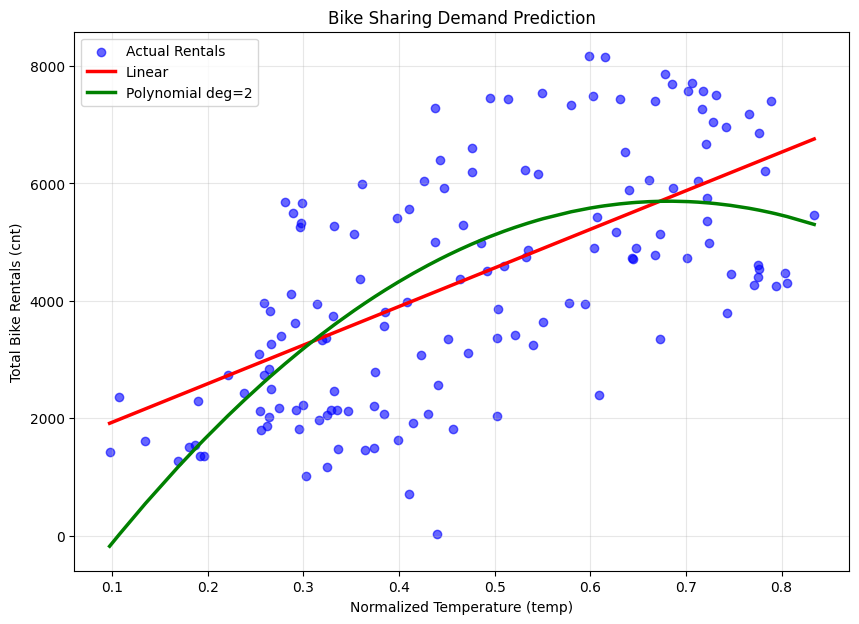

In [29]:
plt.figure(figsize=(10,7))
plt.scatter(X_test_bike, y_test_bike, color='blue', alpha=0.6, label='Actual Rentals')
plt.plot(X_test_bike_sorted, model_bike.predict(X_test_bike[sort_idx_bike]), 
        color='red', linewidth=2.5, label='Linear')
plt.plot(X_test_bike_sorted, model_poly_bike.predict(X_test_poly_bike_sorted), 
        color='green', linewidth=2.5, label='Polynomial deg=2')
plt.xlabel('Normalized Temperature (temp)')
plt.ylabel('Total Bike Rentals (cnt)')
plt.title('Bike Sharing Demand Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
